In [42]:
import pandas as pd
import numpy as np

In [43]:
#excel_file_path2 = 'C:/Users/ASUS/OneDrive/Documents/中信兄弟/Trackman/Statcast/陳偉殷.xlsx'
#sheet_name = 'Sheet1'
#track_u18 = pd.read_excel(excel_file_path2, sheet_name=sheet_name)

In [44]:
track_u18 = pd.read_csv("C:/Users/weisz/OneDrive/Documents/中信兄弟/Trackman/Statcast/Lin, Shih-Hsiang.csv")

In [45]:
pitcher = "Lin, Shih-Hsiang WBC"

In [46]:
output_dir = pitcher

In [47]:
track_u18.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Columns: 118 entries, pitch_type to intercept_ball_minus_batter_pos_y_inches
dtypes: float64(63), int64(38), object(17)
memory usage: 14.0+ KB


In [48]:

track_u18['Year'] = track_u18['game_date'].astype(str).str[:4]

In [49]:
track_u18['VertBreak']=-track_u18['api_break_z_with_gravity']*11.9902405019 
track_u18.loc[track_u18['p_throws'] == 'L', 'api_break_x_arm'] *= -1
track_u18['HorzBreak']=track_u18['api_break_x_arm']*11.9902405019
track_u18['InduceVertBreak']=track_u18['pfx_z']*11.9902405019 


In [50]:
track_u18['plate_x_2'] = -track_u18['plate_x']

In [51]:
name_mapping = {
    'FF':'直球', 
    'CH':'變速球', 
    'FC':'卡特球', 
    'CU':'曲球', 
    'FS':'指叉球',
    'SL':'滑球', 
    'SI':'伸卡球',
    'KC':'彈指曲球', 
    'FO':'指叉球', 
    'CS':'曲球', 
    'ST':'滑球',
    'SV':'滑球',
    'KN':'彈指曲球'  
}

# 新增一列"球員"，根据"Pitcher"列的值匹配中文名
track_u18['球種'] = track_u18['pitch_type'].map(name_mapping)

In [52]:
track_u18

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches,Year,VertBreak,HorzBreak,InduceVertBreak,plate_x_2,球種
0,FF,2026/3/6,91.0,-0.88,6.12,"Lin, Shih-Hsiang",672960,838361,field_out,hit_into_play,...,NaN,NaN,NaN,NaN,2026,-16.426629,13.189265,16.786337,-0.033170,直球
1,FF,2026/3/5,90.1,-1.06,5.97,"Lin, Shih-Hsiang",678521,838361,force_out,hit_into_play,...,NaN,NaN,NaN,NaN,2026,-17.625654,14.028581,16.426629,0.227350,直球
2,CH,2026/3/5,78.8,-1.30,5.85,"Lin, Shih-Hsiang",678521,838361,NaN,called_strike,...,NaN,NaN,NaN,NaN,2026,-41.965842,16.546532,2.637853,0.703219,變速球
3,CH,2026/3/5,78.1,-1.14,5.99,"Lin, Shih-Hsiang",564434,838361,field_out,hit_into_play,...,NaN,NaN,NaN,NaN,2026,-41.006623,13.788777,4.076682,-0.270675,變速球
4,CH,2026/3/5,78.7,-1.25,5.92,"Lin, Shih-Hsiang",564434,838361,NaN,ball,...,NaN,NaN,NaN,NaN,2026,-44.004183,13.908679,0.359707,-0.992975,變速球
5,FF,2026/3/5,89.8,-0.89,6.07,"Lin, Shih-Hsiang",564434,838361,NaN,ball,...,NaN,NaN,NaN,NaN,2026,-16.066922,12.589753,18.105263,-0.047785,直球
6,CH,2026/3/5,77.5,-1.25,5.93,"Lin, Shih-Hsiang",564434,838361,NaN,swinging_strike,...,NaN,NaN,NaN,NaN,2026,-42.565354,13.309167,3.237365,0.726071,變速球
7,CH,2026/3/5,77.8,-1.24,5.94,"Lin, Shih-Hsiang",678534,838361,field_out,hit_into_play,...,NaN,NaN,NaN,NaN,2026,-34.531893,12.829557,10.431509,0.139135,變速球
8,CH,2026/3/5,77.5,-1.31,5.92,"Lin, Shih-Hsiang",678534,838361,NaN,ball,...,NaN,NaN,NaN,NaN,2026,-37.769258,12.110143,7.553852,0.717266,變速球
9,CH,2026/3/5,78.6,-1.35,5.77,"Lin, Shih-Hsiang",673062,838361,single,hit_into_play,...,NaN,NaN,NaN,NaN,2026,-41.126525,15.107703,3.477170,-0.048958,變速球


In [53]:
def calc_angles(row):
    vx0, vy0, vz0 = row['vx0'], row['vy0'], row['vz0']
    ax, ay, az = row['ax'], row['ay'], row['az']
    y0 = row['release_pos_y']  # 這裡改成你的釋放點座標
    yf = 17 / 12
    # 1. 垂直釋放角
    v0 = np.sqrt(vx0**2 + vy0**2 + vz0**2)
    vert_release_angle = np.arcsin(vz0 / v0) * 180 / np.pi
    # 2. 水平釋放角
    horz_release_angle = 360-(180- np.arctan2(vx0, vy0) * 180 / np.pi)
    # 3. 垂直進壘角
    vy_f = -np.sqrt(vy0**2 - 2 * ay * (y0 - yf))
    t = (vy_f - vy0) / ay
    vz_f = vz0 + az * t
    vert_approach_angle = -np.arctan(vz_f / vy_f) * 180 / np.pi
    return pd.Series([vert_release_angle, horz_release_angle, vert_approach_angle])

track_u18[['VerRelAngle', 'HorRelAngle', 'VerAppAngle']] = track_u18.apply(calc_angles, axis=1)

In [54]:
track_u18 = track_u18.rename(columns={ 
    'release_speed': 'RelSpeed', 
    'release_extension': 'Extension', 
    'release_pos_z': 'RelHeight',
    'release_pos_x': 'RelSide',
    'player_name':'Pitcher',
    'plate_x_2':'PlateLocHeight',
    'plate_z':'PlateLocSide',
})

In [55]:
track_u18 = track_u18[~track_u18['pitch_type'].isin(['PO', 'IN','AB','FA','EP'])]

In [56]:
# 預先定義兩種 g 值
#g_fast = 31.174  # 給 FF, FC, SI 使用
#g_others = 32.3  # 其他球種使用

# 計算時間 t（從釋放點到本壘）
#track_u18['t'] = 55 / abs(track_u18['vy0'])  # vy0 為 fps

# 建立一個布林條件，用來判斷是否為指定三種球種
#condition_fast = track_u18['pitch_type'].isin(['FF', 'FC', 'SI','FS','FO','SL','ST'])

# 分別計算 IVB_est
#track_u18.loc[condition_fast, 'IVB_est'] = (
 #   (track_u18.loc[condition_fast, 'az'] + g_fast) *
  #  (track_u18.loc[condition_fast, 't'] ** 2) / 2 * 11.9902405019
#)

#track_u18.loc[~condition_fast, 'IVB_est'] = (
 #   (track_u18.loc[~condition_fast, 'az'] + g_others) *
  #  (track_u18.loc[~condition_fast, 't'] ** 2) / 2 * 11.9902405019
#)


In [57]:
col2 = ['Year','Pitcher','stand','pitch_type','球種','RelSpeed','release_spin_rate','Extension','VertBreak','InduceVertBreak','HorzBreak','RelHeight','RelSide','PlateLocHeight','PlateLocSide','vx0','vy0','vz0','ax','ay','az','VerRelAngle', 'HorRelAngle', 'VerAppAngle','description','events','spin_axis']

In [58]:
track_u18 = track_u18[~track_u18['pitch_type'].isin([0])]

In [59]:
track_2= track_u18[col2]

In [60]:
#track_2.fillna(0, inplace=True)
track_2

,Year,Pitcher,stand,pitch_type,球種,RelSpeed,release_spin_rate,Extension,VertBreak,InduceVertBreak,...,vz0,ax,ay,az,VerRelAngle,HorRelAngle,VerAppAngle,description,events,spin_axis
0,2026,"Lin, Shih-Hsiang",R,FF,直球,91.0,2380,6.1,-16.426629,16.786337,...,-6.216453,-13.865762,29.234051,-14.605102,-2.689102,357.996324,-5.878372,hit_into_play,field_out,220
1,2026,"Lin, Shih-Hsiang",L,FF,直球,90.1,2282,6.0,-17.625654,16.426629,...,-7.727743,-14.355219,30.635853,-14.943362,-3.375598,358.023890,-6.823842,hit_into_play,force_out,223
2,2026,"Lin, Shih-Hsiang",L,CH,變速球,78.8,2042,6.1,-41.965842,2.637853,...,-2.735156,-12.854503,24.348588,-29.935303,-1.365593,358.062821,-9.567136,called_strike,NaN,258
3,2026,"Lin, Shih-Hsiang",R,CH,變速球,78.1,2036,6.1,-41.006623,4.076682,...,-1.890662,-10.904269,22.238735,-29.103912,-0.952598,357.418658,-8.938703,hit_into_play,field_out,260
4,2026,"Lin, Shih-Hsiang",R,CH,變速球,78.7,1927,6.2,-44.004183,0.359707,...,-2.618730,-11.476416,21.645400,-31.627591,-1.309238,356.520435,-9.808404,ball,NaN,262
5,2026,"Lin, Shih-Hsiang",R,FF,直球,89.8,2158,6.1,-16.066922,18.105263,...,-9.712344,-12.970751,28.290191,-13.064577,-4.259554,358.012687,-7.362051,ball,NaN,215
6,2026,"Lin, Shih-Hsiang",R,CH,變速球,77.5,1936,6.0,-42.565354,3.237365,...,-0.699210,-10.067652,22.016811,-29.977160,-0.355220,358.392083,-8.672859,swinging_strike,NaN,267
7,2026,"Lin, Shih-Hsiang",L,CH,變速球,77.8,1875,6.0,-34.531893,10.431509,...,-1.058052,-10.016890,20.277089,-24.721068,-0.534434,357.827941,-7.252487,hit_into_play,field_out,264
8,2026,"Lin, Shih-Hsiang",L,CH,變速球,77.5,1949,6.0,-37.769258,7.553852,...,1.090793,-9.189783,20.436685,-27.201124,0.553280,358.419410,-6.807641,ball,NaN,267
9,2026,"Lin, Shih-Hsiang",R,CH,變速球,78.6,2067,6.0,-41.126525,3.477170,...,-0.079627,-12.062224,23.550291,-29.855353,-0.039856,357.324752,-8.119534,hit_into_play,single,265


In [61]:
# 先分組計算每種 description 的數量
summary2 = track_2.groupby(['Pitcher', 'Year', 'pitch_type'])['description'].value_counts().unstack().fillna(0)

whiff_events = ['swinging_strike', 'swinging_strike_blocked', 'missed_bunt', 'foul_tip']
swing_events = whiff_events + [
    'foul', 'foul_tip', 'foul_bunt', 'bunt_foul_tip', 'hit_into_play'
]

# 補齊所有事件欄位，沒有的自動補0
for col in swing_events:
    if col not in summary2.columns:
        summary2[col] = 0

whiff_count = summary2[whiff_events].sum(axis=1)
swing_count = summary2[swing_events].sum(axis=1)

summary2['Whiff Rate'] = np.where(
    swing_count > 0,
    100 * whiff_count / swing_count,
    0
)

# 整理輸出
summary2 = summary2.reset_index()
summary2 = summary2[['pitch_type', 'Pitcher', 'Year', 'Whiff Rate']]
summary2

description,pitch_type,Pitcher,Year,Whiff Rate
0,CH,"Lin, Shih-Hsiang",2026,25.0
1,FF,"Lin, Shih-Hsiang",2026,0.0
2,FO,"Lin, Shih-Hsiang",2026,0.0


In [62]:
columns_to_group = ['RelSpeed','release_spin_rate','Extension','VertBreak','InduceVertBreak','HorzBreak','RelHeight','RelSide','PlateLocHeight','PlateLocSide','vx0','vy0','vz0','ax','ay','az','VerRelAngle', 'HorRelAngle', 'VerAppAngle','spin_axis']

# 1. 計算平均與數量
grouped = track_2.groupby(['Year', 'Pitcher', 'pitch_type'])
grouped_means = grouped[columns_to_group].mean().reset_index()
grouped_means['count'] = grouped.size().values

# 2. 計算每年各pitch_type的比例
# 先計算每年總數
year_pitcher_total = grouped_means.groupby(['Year', 'Pitcher'])['count'].transform('sum')
grouped_means['proportion'] =100* grouped_means['count'] / year_pitcher_total
grouped_means

,Year,Pitcher,pitch_type,RelSpeed,release_spin_rate,Extension,VertBreak,InduceVertBreak,HorzBreak,RelHeight,...,vz0,ax,ay,az,VerRelAngle,HorRelAngle,VerAppAngle,spin_axis,count,proportion
0,2026,"Lin, Shih-Hsiang",CH,78.330,1991.00,6.060,-39.939491,4.784106,14.304357,5.9070,...,-0.546694,-11.205294,22.039001,-28.840941,-0.274199,357.842388,-8.063869,264.60,10,66.666667
1,2026,"Lin, Shih-Hsiang",FF,90.425,2264.25,6.025,-16.186825,17.505751,12.469850,6.0725,...,-7.495671,-12.940838,29.415949,-13.848800,-3.266690,358.122469,-6.416615,218.25,4,26.666667
2,2026,"Lin, Shih-Hsiang",FO,82.600,1398.00,6.100,-30.814918,9.352388,14.148484,5.9600,...,-5.397348,-12.509631,23.022486,-23.804749,-2.571094,357.336806,-8.516884,239.00,1,6.666667


In [63]:
import pandas as pd
import numpy as np

def convert_spin_axis_to_tilt(spin_axis):
    """
    將 Statcast 的 spin_axis (0-360) 轉換為時鐘格式 (HH:MM)
    """
    if pd.isna(spin_axis):
        return None
    
    # 1. 核心邏輯：將 180 度作為基準旋轉，對齊時鐘 12:00
    # 公式：(spin_axis + 180) % 360
    adjusted_degrees = (spin_axis + 180) % 360
    
    # 2. 計算小時與分鐘
    # 每 30 度為 1 小時
    raw_hours = adjusted_degrees / 30
    
    # 處理 0 點（即 12 點）的情況
    hour = int(raw_hours)
    if hour == 0:
        hour = 12
        
    minutes = int((raw_hours % 1) * 60)
    
    return f"{hour:02d}:{minutes:02d}"


# 應用轉換
grouped_means['tilt'] = grouped_means['spin_axis'].apply(convert_spin_axis_to_tilt)

grouped_means

,Year,Pitcher,pitch_type,RelSpeed,release_spin_rate,Extension,VertBreak,InduceVertBreak,HorzBreak,RelHeight,...,ax,ay,az,VerRelAngle,HorRelAngle,VerAppAngle,spin_axis,count,proportion,tilt
0,2026,"Lin, Shih-Hsiang",CH,78.330,1991.00,6.060,-39.939491,4.784106,14.304357,5.9070,...,-11.205294,22.039001,-28.840941,-0.274199,357.842388,-8.063869,264.60,10,66.666667,02:49
1,2026,"Lin, Shih-Hsiang",FF,90.425,2264.25,6.025,-16.186825,17.505751,12.469850,6.0725,...,-12.940838,29.415949,-13.848800,-3.266690,358.122469,-6.416615,218.25,4,26.666667,01:16
2,2026,"Lin, Shih-Hsiang",FO,82.600,1398.00,6.100,-30.814918,9.352388,14.148484,5.9600,...,-12.509631,23.022486,-23.804749,-2.571094,357.336806,-8.516884,239.00,1,6.666667,01:57


In [64]:
merged = pd.merge(grouped_means, summary2, on=['Year', 'Pitcher', 'pitch_type'], how='outer')
merged

,Year,Pitcher,pitch_type,RelSpeed,release_spin_rate,Extension,VertBreak,InduceVertBreak,HorzBreak,RelHeight,...,ay,az,VerRelAngle,HorRelAngle,VerAppAngle,spin_axis,count,proportion,tilt,Whiff Rate
0,2026,"Lin, Shih-Hsiang",CH,78.330,1991.00,6.060,-39.939491,4.784106,14.304357,5.9070,...,22.039001,-28.840941,-0.274199,357.842388,-8.063869,264.60,10,66.666667,02:49,25.0
1,2026,"Lin, Shih-Hsiang",FF,90.425,2264.25,6.025,-16.186825,17.505751,12.469850,6.0725,...,29.415949,-13.848800,-3.266690,358.122469,-6.416615,218.25,4,26.666667,01:16,0.0
2,2026,"Lin, Shih-Hsiang",FO,82.600,1398.00,6.100,-30.814918,9.352388,14.148484,5.9600,...,23.022486,-23.804749,-2.571094,357.336806,-8.516884,239.00,1,6.666667,01:57,0.0


In [65]:
#grouped_means.to_excel('Trey_Supak.xlsx', index=True)

In [83]:
# 自訂每個 pitch_type 的顏色
custom_palette = {
    'FF': '#FF0000',   # 紅色
    'SI': '#FFA500',   # 橘色
    'FC': '#FF77FF',   # 粉紅色
    'CH': '#006030',   # 深綠色
    'FS': '#1E90FF',   # 亮藍色
    'FO': '#00DB00',   # 橄欖色
    'SC': '#00CACA',   # 青綠色
    'CU': '#800080',   # 紫色
    'KC': '#5E005E',   # 深紫色
    'CS': '#00BFFF',   # 天藍色
    'SL': '#3D7878',   # 深藍色
    'ST': '#95CACA',   # 淺藍色
    'SV': '#FFD700',   # 亮黃色
    'KN': '#949449',   # 灰綠色
}

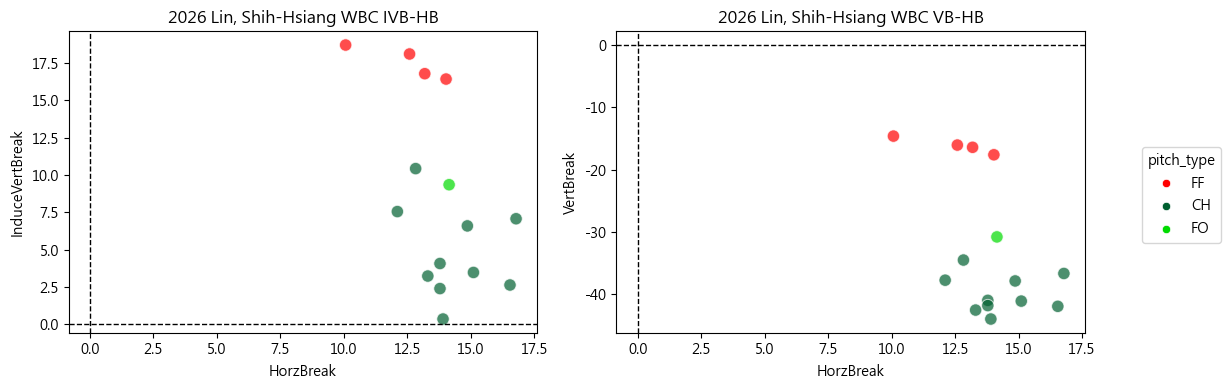

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import os

# 設定中文字體
matplotlib.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'SimHei', 'Arial']
matplotlib.rcParams['axes.unicode_minus'] = False

# 確保 'Year' 是數字格式
track_u18['Year'] = track_u18['Year'].astype(int)

years = sorted(track_u18['Year'].unique())
n_years = len(years)

fig, axes = plt.subplots(n_years, 2, figsize=(12, 4 * n_years), sharex=False, sharey=False)

# 先畫所有子圖（都不產生 legend）
for i, year in enumerate(years):
    df_year = track_u18[track_u18['Year'] == year]
    # 左圖：IVB-HB
    ax1 = axes[i, 0] if n_years > 1 else axes[0]
    sns.scatterplot(
        data=df_year, x="HorzBreak", y="InduceVertBreak", hue="pitch_type",
        palette=custom_palette, alpha=0.7, edgecolor='w', s=80, ax=ax1, legend=False
    )
    ax1.axhline(0, color='black', linewidth=1, linestyle='--')
    ax1.axvline(0, color='black', linewidth=1, linestyle='--')
    ax1.set_title(f"{year} {pitcher} IVB-HB")
    ax1.set_xlabel("HorzBreak")
    ax1.set_ylabel("InduceVertBreak")
    #ax1.text(0.02, 0.95, f"Year: {year}", transform=ax1.transAxes,
     #        fontsize=12, fontweight='bold', ha='left', va='top')
    # 右圖：VB-HB
    ax2 = axes[i, 1] if n_years > 1 else axes[1]
    sns.scatterplot(
        data=df_year, x="HorzBreak", y="VertBreak", hue="pitch_type",
        palette=custom_palette, alpha=0.7, edgecolor='w', s=80, ax=ax2, legend=False
    )
    ax2.axhline(0, color='black', linewidth=1, linestyle='--')
    ax2.axvline(0, color='black', linewidth=1, linestyle='--')
    ax2.set_title(f"{year} {pitcher} VB-HB")
    ax2.set_xlabel("HorzBreak")
    ax2.set_ylabel("VertBreak")
    #ax2.text(0.02, 0.95, f"Year: {year}", transform=ax2.transAxes,
     #        fontsize=12, fontweight='bold', ha='left', va='top')

plt.tight_layout(rect=[0, 0, 0.93, 1])  # 預留右側空間給圖例

# 只用一個 axes 來取得 handles/labels（用最後一個子圖產生的圖例資訊）
# 這裡用一個臨時的 scatterplot 來產生 legend handles
import numpy as np
dummy_ax = fig.add_axes([0,0,0.1,0.1])
dummy_ax.axis('off')
dummy = sns.scatterplot(
    data=track_u18, x="HorzBreak", y="InduceVertBreak", hue="pitch_type",
    palette=custom_palette, alpha=1, ax=dummy_ax
)
handles, labels = dummy_ax.get_legend_handles_labels()
dummy_ax.remove()

fig.legend(handles, labels, title="pitch_type", loc='center left', bbox_to_anchor=(0.95, 0.5), frameon=True)

# 輸出
#output_dir = "洋將"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, f"{pitcher.replace(' ', '_')}_IVB-HB_VB-HB_byYear.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

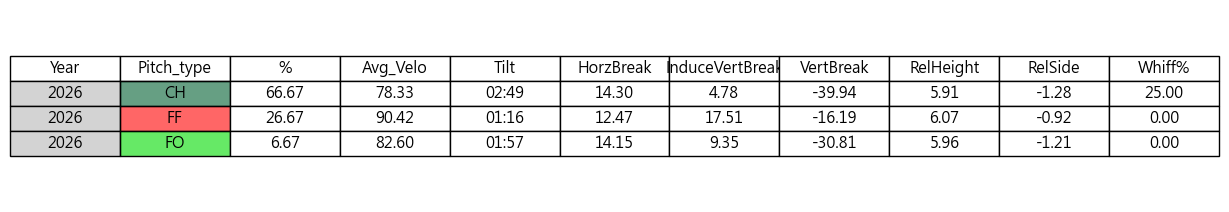

In [85]:
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.font_manager as fm
import matplotlib.colors as mcolors
import os

matplotlib.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'SimHei', 'Arial']
matplotlib.rcParams['axes.unicode_minus'] = False

show_cols = ['Year','pitch_type','proportion','RelSpeed','tilt', 'HorzBreak', 'InduceVertBreak', 'VertBreak','RelHeight','RelSide','Whiff Rate']

avg_table = merged[show_cols]

def format_cell(col, val):
    if col == 'Year':
        return str(int(val))
    elif col == 'pitch_name':
        return str(val)
    else:
        try:
            return f"{float(val):.2f}"
        except:
            return str(val)
avg_table_fmt = avg_table.copy()
for col in avg_table_fmt.columns:
    avg_table_fmt[col] = avg_table_fmt[col].apply(lambda x: format_cell(col, x))
col_rename = {
    'Year': 'Year',
    'pitch_type': 'Pitch_type',
    'proportion': '%',
    'RelSpeed': 'Avg_Velo',
    'tilt':'Tilt',
    'HorzBreak': 'HorzBreak',
    'InduceVertBreak': 'InduceVertBreak',
    'VertBreak': 'VertBreak',
    'RelHeight': 'RelHeight',
    'RelSide': 'RelSide',
    'Whiff Rate': 'Whiff%'
}
avg_table_fmt = avg_table_fmt.rename(columns=col_rename)


fig2, ax2 = plt.subplots(figsize=(12, 1 + 0.5 * len(avg_table_fmt)))
ax2.axis('off')
mpl_table = ax2.table(
    cellText=avg_table_fmt.values,
    colLabels=avg_table_fmt.columns,
    loc='center',
    cellLoc='center',
    colLoc='center',
    edges='closed'
)
mpl_table.auto_set_font_size(False)
mpl_table.set_fontsize(11)
mpl_table.scale(1.3, 1.5)

# 根據 Pitch_type 給予顏色
pitch_col_idx = list(avg_table_fmt.columns).index('Pitch_type')
for row_idx, pitch in enumerate(avg_table_fmt['Pitch_type']):
    base_color = custom_palette.get(pitch, "#FFFFFF")
    rgba = mcolors.to_rgba(base_color, alpha=0.6)  # 0.25 可依需求調整
    for col_idx in range(len(avg_table_fmt.columns)):
        cell = mpl_table[(row_idx+1, col_idx)]  # +1 因為第0行是標題
        cell.set_facecolor(rgba if col_idx == pitch_col_idx else "#FFFFFF") 

# 根據 Year 欄位的奇偶年給予不同背景色，只影響 Year 欄
year_col_idx = list(avg_table_fmt.columns).index('Year')
for row_idx in range(len(avg_table_fmt)):
    year_val = avg_table_fmt.iloc[row_idx]['Year']
    try:
        year = int(year_val)
        color = '#D3D3D3' if year % 2 == 0 else '#FDEDEC'  # 偶數年淡青、奇數年淡粉
    except:
        color = '#FFFFFF'
    cell = mpl_table[(row_idx + 1, year_col_idx)]  # 只設定 Year 欄位
    cell.set_facecolor(color)
        
# 若你想整行都上色，請把上面 if col_idx == pitch_col_idx 拿掉
# for row_idx, pitch in enumerate(avg_table_fmt['Pitch_type']):
#     color = custom_palette.get(pitch, "#FFFFFF")
#     for col_idx in range(len(avg_table_fmt.columns)):
#         cell = mpl_table[(row_idx+1, col_idx)]
#         cell.set_facecolor(color)



for key, cell in mpl_table.get_celld().items():
    cell.set_linewidth(1)
    cell.set_edgecolor('black')
    # cell.set_fontproperties(fm.FontProperties(fname='C:/Windows/Fonts/msjh.ttc'))  # 若要指定字型

#output_dir = "圖表"
os.makedirs(output_dir, exist_ok=True)
output_path2 = os.path.join(output_dir, f"{pitcher.replace(' ', '_')}(IVB-HB_VB-HB)_table.png")
plt.savefig(output_path2, dpi=300, bbox_inches='tight')
plt.show()

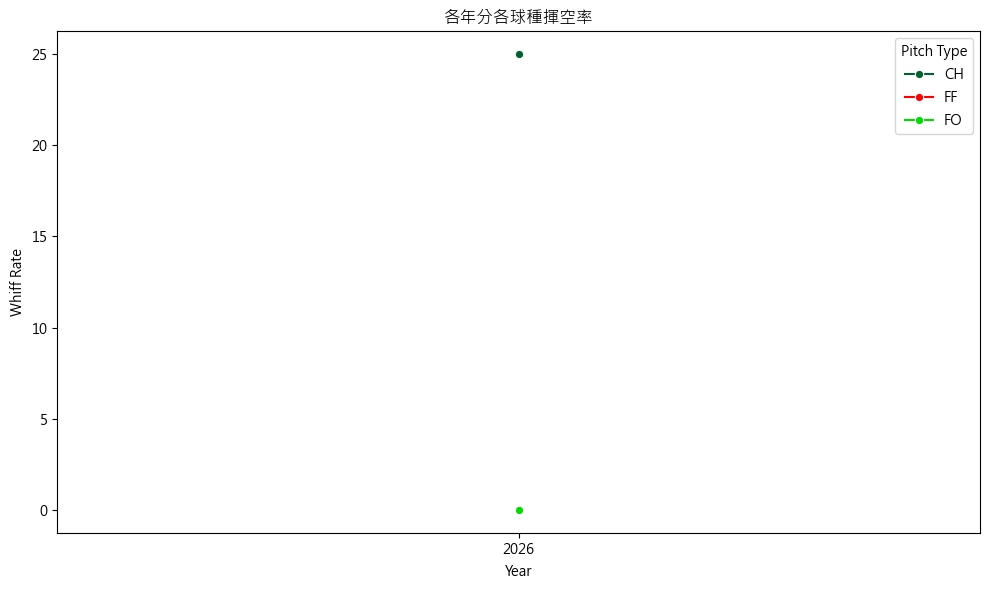

In [86]:
# 假設你的資料已經在 grouped_means 這個 DataFrame
# 1. 各年分各球種的揮空率折線圖
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=merged,
    x='Year',
    y='Whiff Rate',
    hue='pitch_type',
    palette=custom_palette,
    marker='o'
)
plt.title('各年分各球種揮空率')
plt.ylabel('Whiff Rate')
plt.xlabel('Year')
plt.legend(title='Pitch Type')
plt.tight_layout()
output_path = os.path.join(output_dir, f"{pitcher.replace(' ', '_')}_whiff_rate_by_year_pitchtype.png")
plt.savefig(output_path, dpi=300)
plt.show()



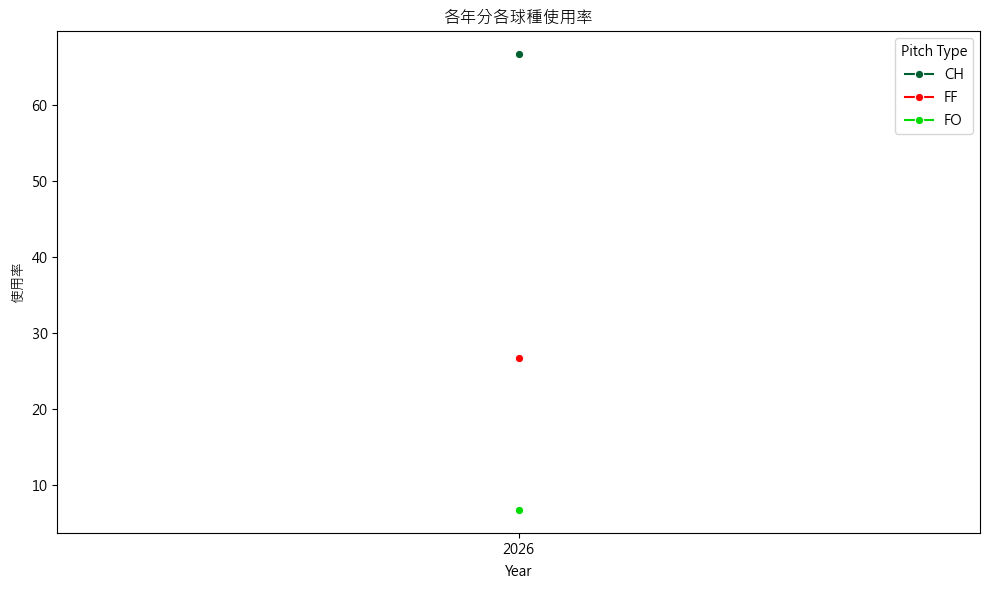

In [87]:
# 2. 各年分各球種的使用率(proportion)折線圖
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=merged,
    x='Year',
    y='proportion',
    hue='pitch_type',
    palette=custom_palette,
    marker='o'
)
plt.title('各年分各球種使用率')
plt.ylabel('使用率')
plt.xlabel('Year')
plt.legend(title='Pitch Type')
plt.tight_layout()
output_path = os.path.join(output_dir, f"{pitcher.replace(' ', '_')}_proportion_by_year_pitchtype.png")
plt.savefig(output_path, dpi=300)
plt.show()

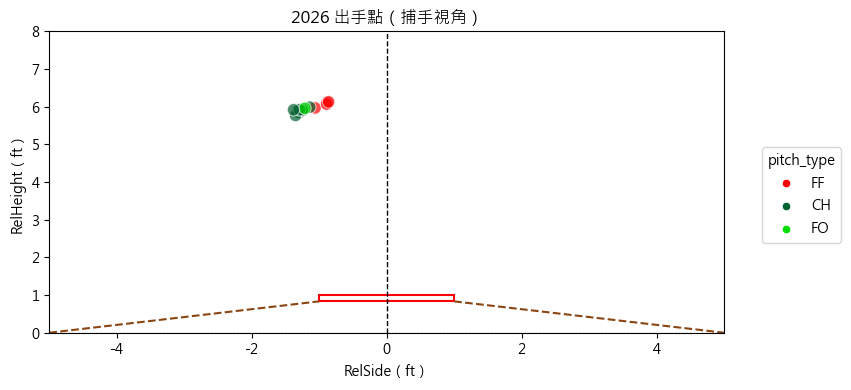

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import os

# 自訂每個 pitch_type 的顏色
custom_palette = {
    'FF': '#FF0000',   # 紅色
    'SI': '#FFA500',   # 橘色
    'FC': '#FF77FF',   # 粉紅色
    'CH': '#006030',   # 深綠色
    'FS': '#1E90FF',   # 亮藍色
    'FO': '#00DB00',   # 橄欖色
    'SC': '#00CACA',   # 青綠色
    'CU': '#800080',   # 紫色
    'KC': '#5E005E',   # 深紫色
    'CS': '#00BFFF',   # 天藍色
    'SL': '#3D7878',   # 深藍色
    'ST': '#95CACA',   # 淺藍色
    'SV': '#FFD700',   # 亮黃色
    'KN': '#949449',   # 灰綠色
}

# 設定中文字體
matplotlib.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'SimHei', 'Arial']
matplotlib.rcParams['axes.unicode_minus'] = False

# 確保 'Year' 是數字格式
track_u18['Year'] = track_u18['Year'].astype(int)

years = sorted(track_u18['Year'].unique())
n_years = len(years)

fig, axes = plt.subplots(n_years, 1, figsize=(8, 4 * n_years), sharex=False, sharey=False)

# 當只有一張圖時也統一使用 list 方式處理 axes
if n_years == 1:
    axes = [axes]

for i, year in enumerate(years):
    df_year = track_u18[track_u18['Year'] == year]
    ax = axes[i]

    # 繪製散點圖（出手點）
    sns.scatterplot(
        data=df_year, x="RelSide", y="RelHeight", hue="pitch_type",
        palette=custom_palette, alpha=0.7, edgecolor='w', s=80, ax=ax, legend=False
    )

    # 輔助線：X = 0（投手正中央）
    ax.axvline(0, color='black', linewidth=1, linestyle='--')

    # 地面線（Y=0）
    ax.axhline(0, color='gray', linestyle=':', linewidth=1)

    # 投手板（寬 2 ft、高 0.167 ft，底部在投手丘 0.833 ft）
    rect = plt.Rectangle((-1, 0.833), 2, 0.167, linewidth=1.5, edgecolor='red', facecolor='none')
    ax.add_patch(rect)

    # 新增投手丘斜坡線條（模擬投手丘）
    ax.plot([-5, -1], [0, 0.833], color='saddlebrown', linestyle='--', linewidth=1.5)  # 左斜坡
    ax.plot([1, 5], [0.833, 0], color='saddlebrown', linestyle='--', linewidth=1.5)    # 右斜坡

    ax.set_title(f"{year} 出手點（捕手視角）")
    ax.set_xlabel("RelSide（ft）")
    ax.set_ylabel("RelHeight（ft）")
    ax.set_xlim(-5, 5)
    ax.set_ylim(0, max(df_year['RelHeight'].max(), 8))  # 預留空間給投手板框


plt.tight_layout(rect=[0, 0, 0.93, 1])  # 預留右側空間給圖例

# 產生 legend（使用透明圖層抓 hue）
import numpy as np
dummy_ax = fig.add_axes([0,0,0.1,0.1])
dummy_ax.axis('off')
dummy = sns.scatterplot(
    data=track_u18, x="RelSide", y="RelHeight", hue="pitch_type",
    palette=custom_palette, alpha=1, ax=dummy_ax
)
handles, labels = dummy_ax.get_legend_handles_labels()
dummy_ax.remove()

fig.legend(handles, labels, title="pitch_type", loc='center left', bbox_to_anchor=(0.95, 0.5), frameon=True)

# 輸出
#output_dir = "圖表"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, f"{pitcher.replace(' ', '_')}_出手點_byYear.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

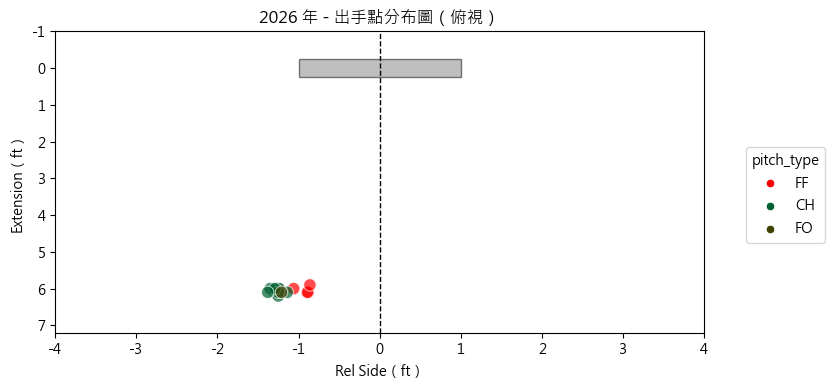

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import os
import matplotlib.patches as patches
import numpy as np

# 設定字型（中文支援）
matplotlib.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
matplotlib.rcParams['axes.unicode_minus'] = False

# 色彩設定
custom_palette = {
    'FF': '#FF0000', 'SI': '#FFA500', 'FC': '#FF77FF', 'CH': '#006030', 'FS': '#1E90FF',
    'FO': '#424200', 'SC': '#00CACA', 'CU': '#800080', 'KC': '#5E005E', 'CS': '#00BFFF',
    'SL': '#3D7878', 'ST': '#95CACA', 'SV': '#FFD700', 'KN': '#949449',
}

# 確保年份為整數
track_u18['Year'] = track_u18['Year'].astype(int)
years = sorted(track_u18['Year'].unique())

# 建立子圖
fig, axes = plt.subplots(len(years), 1, figsize=(8, 4 * len(years)))
if len(years) == 1:
    axes = [axes]

for i, year in enumerate(years):
    ax = axes[i]
    df_year = track_u18[track_u18['Year'] == year]

    # 畫出出手點（俯視圖）
    sns.scatterplot(
        data=df_year, x="RelSide", y="Extension", hue="pitch_type",
        palette=custom_palette, alpha=0.7, edgecolor='w', s=80, ax=ax, legend=False
    )

    # 畫投手板（設定在 extension = 0 位置）
    mound_width = 2  # 英尺
    mound_depth = 0.5  # 英尺
    mound_center_x = 0
    mound_y = 0
    mound_left = mound_center_x - mound_width / 2
    mound_bottom = mound_y - mound_depth / 2
    mound = patches.Rectangle(
        (mound_left, mound_bottom), mound_width, mound_depth,
        linewidth=1, edgecolor='black', facecolor='gray', alpha=0.5
    )
    ax.add_patch(mound)

    # 畫輔助線
    ax.axvline(0, color='black', linestyle='--', linewidth=1)

    # 設定座標軸
    ax.set_xlabel("Rel Side（ft）")
    ax.set_ylabel("Extension（ft）")
    ax.set_title(f"{year} 年 - 出手點分布圖（俯視）")

    # Y 軸反轉（最大在上，最小在下），加入數值檢查
    min_ext = df_year["Extension"].min()
    max_ext = df_year["Extension"].max()
    if np.isfinite(min_ext) and np.isfinite(max_ext):
        min_ext = min(min_ext, 0)
        ax.set_ylim(max_ext + 1, min_ext - 1)
    else:
        # Fallback 若資料有缺漏
        ax.set_ylim(5, -3)

    # X 軸正常設定
    ax.set_xlim(-4, 4)

# 加入 legend
dummy_ax = fig.add_axes([0, 0, 0.1, 0.1])
dummy_ax.axis('off')
dummy = sns.scatterplot(
    data=track_u18, x="RelSide", y="Extension", hue="pitch_type",
    palette=custom_palette, alpha=1, ax=dummy_ax
)
handles, labels = dummy_ax.get_legend_handles_labels()
dummy_ax.remove()
fig.legend(handles, labels, title="pitch_type", loc='center left', bbox_to_anchor=(0.93, 0.5), frameon=True)

# 輸出圖片
plt.tight_layout(rect=[0, 0, 0.91, 1])
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, f"{pitcher.replace(' ', '_')}_出手點_俯視_byYear.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()




In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import os

# 設定中文字體
matplotlib.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'SimHei', 'Arial']
matplotlib.rcParams['axes.unicode_minus'] = False

# colormap（紅→藍）
cmap = "coolwarm"

# 定義好球帶矩形
def draw_strike_zone(ax):
    strike_zone = plt.Rectangle(
        (-0.83, 1.5), 1.66, 2.0,
        linewidth=1.5, edgecolor='black', facecolor='none'
    )
    ax.add_patch(strike_zone)

# 指定投手與輸出資料夾
#pitcher = track_u18['Pitcher'].iloc[0] if 'Pitcher' in track_u18.columns else "Pitcher"
#output_dir = "圖表"
os.makedirs(output_dir, exist_ok=True)

# 年度與球種資訊
track_u18['Year'] = track_u18['Year'].astype(int)
years = sorted(track_u18['Year'].unique())

# 對左右打者各自產圖
for stand in ['R', 'L']:
    df_stand_all = track_u18[track_u18['stand'] == stand]
    n_rows = len(years)
    max_pitch_types = max(df_stand_all[df_stand_all['Year'] == y]['pitch_type'].nunique() for y in years)

    fig, axes = plt.subplots(n_rows, max_pitch_types, figsize=(5 * max_pitch_types, 6 * n_rows), sharex=True, sharey=True)

    # 調整 axes 結構成 2D 陣列
    if n_rows == 1:
        axes = [axes]
    if max_pitch_types == 1:
        axes = [[ax] for ax in axes]

    for row_idx, year in enumerate(years):
        df_year = df_stand_all[df_stand_all['Year'] == year].dropna(subset=['PlateLocHeight', 'PlateLocSide', 'pitch_type'])
        pitch_types = df_year['pitch_type'].unique()

        for col_idx in range(max_pitch_types):
            ax = axes[row_idx][col_idx]
            ax.set_xlim(-2, 2)
            ax.set_ylim(0, 5)
            ax.axis('off')

            if col_idx < len(pitch_types):
                pitch = pitch_types[col_idx]
                df_pitch = df_year[df_year['pitch_type'] == pitch]

                if len(df_pitch) >= 5 and df_pitch['PlateLocHeight'].nunique() > 1 and df_pitch['PlateLocSide'].nunique() > 1:
                    sns.kdeplot(
                        x=df_pitch['PlateLocHeight'],
                        y=df_pitch['PlateLocSide'],
                        fill=True,
                        cmap=cmap,
                        bw_adjust=0.5,
                        levels=100,
                        thresh=0.1,
                        alpha=1,
                        ax=ax
                    )
                else:
                    ax.text(0, 2.5, '資料不足', ha='center', va='center', fontsize=12, color='gray')

                draw_strike_zone(ax)
                total = len(df_pitch)
                percent = total / len(df_year) * 100 if len(df_year) > 0 else 0
                ax.set_title(f"{pitch}\n{total} Pitches ({percent:.1f}%)", fontsize=12, color='#B22222')
            else:
                ax.text(0, 2.5, '無球種資料', ha='center', va='center', fontsize=12, color='gray')

            if col_idx == 0:
                ax.text(-1.9, 4.7, f"{year} 面對 {stand} 投手視角", fontsize=16, fontweight='bold', color='black')

    plt.tight_layout()
    output_path = os.path.join(output_dir, f"{pitcher}_{stand}_all_years_plate_heatmaps.png")
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close(fig)  # 關閉當前圖表，避免與下一張重疊

## 軌跡圖

In [91]:
data = track_u18.copy()

In [92]:
pitch_labels = dict(
    FF='FF',
    SI='SI',
    FC='FC',
    CH='CH',
    FS='FS',
    FO='FO',
    SC='SC',
    CU='CU',
    KC='KC',
    CS='CS',
    SL='SL',
    ST='ST',   
    SV='SV',
    KN='KN',
)
pitch_colors = {
    'FF': '#FF0000',   # 紅色
    'SI': '#FFA500',   # 橘色
    'FC': '#FF77FF',   # 粉紅色
    'CH': '#006030',   # 深綠色
    'FS': '#1E90FF',   # 亮藍色
    'FO': '#00DB00',   # 橄欖色
    'SC': '#00CACA',   # 青綠色
    'CU': '#800080',   # 紫色
    'KC': '#5E005E',   # 深紫色
    'CS': '#00BFFF',   # 天藍色
    'SL': '#3D7878',   # 深藍色
    'ST': '#95CACA',   # 淺藍色
    'SV': '#FFD700',   # 亮黃色
    'KN': '#949449',   # 灰綠色
}
strike_zone_label = "Strike Zone"
desired_pitches = list(pitch_labels.keys())

In [93]:
# 如果 release_pos_y 為空值，以 56 替代
data['Extension'] = data['Extension'].fillna(55)

In [94]:
# Flip lateral positions to correct mound side (right side positive)
#data['RelSide'] = data['RelSide']
#data['vx0'] = -data['vx0']
#data['ax'] = -data['ax']

In [95]:
years = sorted(data['Year'].unique())

In [96]:
import pandas as pd

# 確保 delta_pitcher_run_exp 為數值型態
data['delta_pitcher_run_exp'] = pd.to_numeric(data['delta_pitcher_run_exp'], errors='coerce')

# 1. 定義篩選函數
def filter_top_10_percent(group):
    # 計算該組別（特定年份+特定球種）的第 90 百分位數
    # 如果該組資料太少（例如只有 1 筆），quantile 仍會運作，但建議確保數據量
    threshold = group['delta_pitcher_run_exp'].quantile(0.9)
    return group[group['delta_pitcher_run_exp'] >= threshold]

# 2. 執行分組篩選：同時針對 'Year' 和 'pitch_type'
# group_keys=False 確保不會改變原始 DataFrame 的索引結構
filtered_data = data.groupby(['Year', 'pitch_type'], group_keys=False).apply(filter_top_10_percent)

# 3. 排序讓結果更直觀
filtered_data = filtered_data.sort_values(['Year', 'pitch_type', 'delta_pitcher_run_exp'], 
                                          ascending=[True, True, False])

# 查看結果
filtered_data

C:\Users\weisz\AppData\Local\Temp\ipykernel_15096\3205872081.py:15: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,pitch_type,game_date,RelSpeed,RelSide,RelHeight,Pitcher,batter,pitcher,events,description,...,intercept_ball_minus_batter_pos_y_inches,Year,VertBreak,HorzBreak,InduceVertBreak,PlateLocHeight,球種,VerRelAngle,HorRelAngle,VerAppAngle
7,CH,2026/3/5,77.8,-1.24,5.94,"Lin, Shih-Hsiang",678534,838361,field_out,hit_into_play,...,NaN,2026,-34.531893,12.829557,10.431509,0.139135,變速球,-0.534434,357.827941,-7.252487
0,FF,2026/3/6,91.0,-0.88,6.12,"Lin, Shih-Hsiang",672960,838361,field_out,hit_into_play,...,NaN,2026,-16.426629,13.189265,16.786337,-0.033170,直球,-2.689102,357.996324,-5.878372
13,FO,2026/3/5,82.6,-1.21,5.96,"Lin, Shih-Hsiang",673062,838361,NaN,ball,...,NaN,2026,-30.814918,14.148484,9.352388,-0.248499,指叉球,-2.571094,357.336806,-8.516884


C:\Users\weisz\AppData\Local\Temp\ipykernel_15096\2494571281.py:138: DeprecationWarning:


Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.




✅ 已成功將 Lin, Shih-Hsiang WBC 的軌跡圖輸出至: Lin, Shih-Hsiang WBC\Lin, Shih-Hsiang WBC_Pitch_Trajectory.png


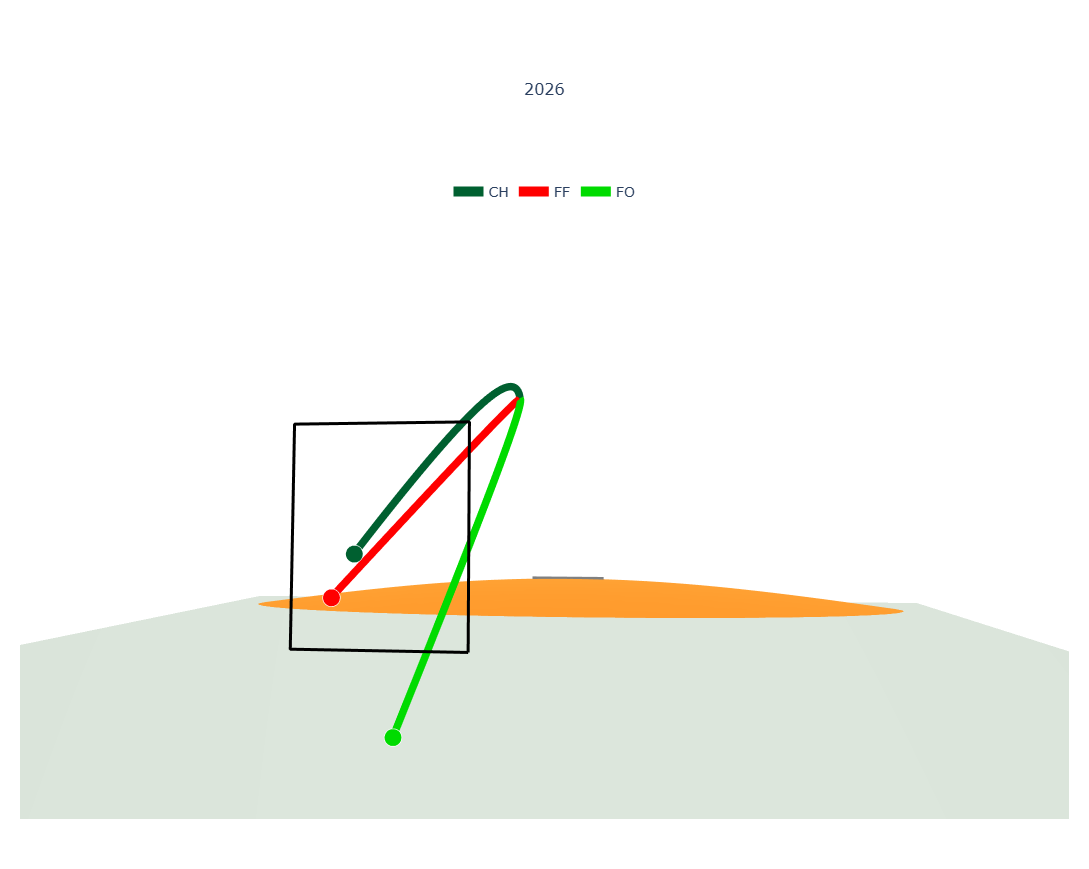

In [97]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- 1. 資料預處理與統計量計算 ---
stats_cols = [
    'RelSide', 'RelHeight', 'RelSpeed', 
    'vx0', 'vy0', 'vz0', 
    'ax', 'ay', 'az', 
    'release_pos_y', 'Extension', 'pfx_x', 'pfx_z'
]

# 計算平均值與標準差
agg_ops = {col: ['mean', 'std'] for col in stats_cols}
avg_data = filtered_data.groupby(['Year', 'pitch_type']).agg(agg_ops).reset_index()

# 扁平化欄位名稱 (例如: ('vx0', 'mean') -> 'vx0_mean')
avg_data.columns = [f"{col}_{stat}" if stat else col for col, stat in avg_data.columns]

# 出手點中心化基準
mean_rel_side = filtered_data['RelSide'].mean()
mean_rel_height = filtered_data['RelHeight'].mean()
years = sorted(filtered_data['Year'].unique())

# --- 2. 物理與環境預算 (原封不動) ---
mound_height, mound_radius = 0.8202, 9.0
theta_m = np.linspace(0, 2*np.pi, 50)
r_m = np.linspace(0, mound_radius, 20)
T_m, R_m = np.meshgrid(theta_m, r_m)
m_x_circle, m_y_circle = R_m * np.cos(T_m), R_m * np.sin(T_m) + 60.5
m_z_circle = mound_height * np.cos((R_m / mound_radius) * (np.pi / 2))
rubber_x, rubber_y, rubber_z = [-1, 1], [60.5, 60.5], [mound_height + 0.02] * 2
visual_sz_width = 1.5
sz_top, sz_bottom = 3.5, 1.5
half_w = visual_sz_width / 2
hp_x, hp_y = [half_w, -half_w, -half_w, 0, half_w], [0, 0, -0.70, -1.2, -0.70]
hp_z = [0.01] * 5
v_sz_x, sz_y, sz_z = [half_w, -half_w, -half_w, half_w, half_w], [0, 0, 0, 0, 0], [sz_bottom, sz_bottom, sz_top, sz_top, sz_bottom]

# --- 3. 畫布初始化 ---
num_years = len(years)
cols = min(num_years, 3)
rows = (num_years + cols - 1) // cols
fig = make_subplots(
    rows=rows, cols=cols,
    subplot_titles=[f"{year}" for year in years],
    specs=[[{'type': 'scatter3d'}] * cols] * rows,
    horizontal_spacing=0.01, vertical_spacing=0.05
)

# --- 4. 繪圖核心邏輯 ---
def get_trajectory(row, suffix='_mean'):
    """根據後綴計算軌跡 (mean, upper, lower)"""
    # 這裡我們讓變動後的物理量影響軌跡，若 std 為 NaN 則補 0
    vy0 = row[f'vy0{suffix}']
    ay = row[f'ay{suffix}']
    start_y = row[f'release_pos_y{suffix}']
    
    # 求解時間 t
    a_quad, b_quad, c_quad = 0.5 * ay, vy0, start_y
    delta = max(0, b_quad**2 - 4*a_quad*c_quad)
    t_total = (-b_quad - np.sqrt(delta)) / (2*a_quad)
    t_vals = np.linspace(0, t_total, 80)
    
    x = mean_rel_side + row[f'vx0{suffix}']*t_vals + 0.5*row[f'ax{suffix}']*t_vals**2
    y = start_y + vy0*t_vals + 0.5*ay*t_vals**2
    z = mean_rel_height + row[f'vz0{suffix}']*t_vals + 0.5*row[f'az{suffix}']*t_vals**2
    return x, y, z

for i, year in enumerate(years):
    curr_row, curr_col = (i // cols) + 1, (i % cols) + 1
    
    # [A] 環境繪製 (原封不動)
    fig.add_trace(go.Surface(x=np.array([[-15, 15], [-15, 15]]), y=np.array([[-5, -5], [75, 75]]), z=np.zeros((2,2)), colorscale=[[0, '#ccd6cc'], [1, '#ccd6cc']], showscale=False, opacity=1, hoverinfo='skip'), row=curr_row, col=curr_col)
    fig.add_trace(go.Surface(x=m_x_circle, y=m_y_circle, z=m_z_circle, colorscale=[[0, '#FF9224'], [1, '#FF9224']], showscale=False, opacity=1, hoverinfo='skip'), row=curr_row, col=curr_col)
    fig.add_trace(go.Scatter3d(x=rubber_x, y=rubber_y, z=rubber_z, mode='lines', line=dict(color='gray', width=6), showlegend=False), row=curr_row, col=curr_col)
    fig.add_trace(go.Mesh3d(x=hp_x, y=hp_y, z=hp_z, color='white', opacity=1, alphahull=0, showlegend=False), row=curr_row, col=curr_col)
    fig.add_trace(go.Scatter3d(x=v_sz_x, y=sz_y, z=sz_z, mode='lines', line=dict(color='black', width=6), showlegend=False), row=curr_row, col=curr_col)

    # [B] 軌跡計算
    df_year = avg_data[avg_data['Year'] == year]
    for _, row in df_year.iterrows():
        p_color = pitch_colors.get(row['pitch_type'], 'gray')
        
        # 建立 Upper (+1std) 與 Lower (-1std) 的數據行
        row_up = {f"{c}_mean": row[f"{c}_mean"] + row[f"{c}_std"] for c in stats_cols}
        row_lo = {f"{c}_mean": row[f"{c}_mean"] - row[f"{c}_std"] for c in stats_cols}
        
        # 1. 繪製平均軌跡 (實線)
        mx, my, mz = get_trajectory(row, '_mean')
        hover_t = (f"Pitch: {row['pitch_type']}<br>"
                   f"Avg Speed: {row['RelSpeed_mean']:.1f} mph<br>"
                   f"Avg Horz Mov (pfx_x): {row['pfx_x_mean']:.2f} ft<br>"
                   f"Avg Vert Mov (pfx_z): {row['pfx_z_mean']:.2f} ft")
        
        fig.add_trace(go.Scatter3d(
            x=mx, y=my, z=mz, mode='lines', 
            line=dict(color=p_color, width=15),
            name=row['pitch_type'], text=hover_t, hoverinfo='text',
            legendgroup=row['pitch_type'], showlegend=(i == 0)
        ), row=curr_row, col=curr_col)

        # 2. 繪製 ±1 Std 軌跡 (細虛線或半透明線)
        for r_bound in [row_up, row_lo]:
            bx, by, bz = get_trajectory(r_bound, '_mean')
            fig.add_trace(go.Scatter3d(
                x=bx, y=by, z=bz, mode='lines',
                line=dict(color=p_color, width=3, dash='dash'),
                opacity=0.4, hoverinfo='skip',
                legendgroup=row['pitch_type'], showlegend=False
            ), row=curr_row, col=curr_col)

        # 3. 平均進壘點標記
        fig.add_trace(go.Scatter3d(
            x=[mx[-1]], y=[my[-1]], z=[mz[-1]], 
            mode='markers', marker=dict(color=p_color, size=10, line=dict(color='white', width=1)),
            showlegend=False, hoverinfo='skip'
        ), row=curr_row, col=curr_col)

# --- 5. 視覺參數設定 (原封不動) ---
camera_setting = dict(eye=dict(x=0.35, y=-2.5, z=-0.2), center=dict(x=0, y=0.5, z=0), up=dict(x=0, y=0, z=1))
scene_config = dict(xaxis=dict(range=[-10, 10], visible=False), yaxis=dict(range=[-8, 68], visible=False), zaxis=dict(range=[0, 8], visible=False), camera=camera_setting, aspectratio=dict(x=3.2, y=3.5, z=1.2), aspectmode='manual')
fig.update_scenes(**scene_config)
fig.update_layout(paper_bgcolor='white', margin=dict(l=20, r=20, b=50, t=100), legend=dict(orientation="h", yanchor="bottom", y=0.85, xanchor="center", x=0.5, font=dict(size=14)), height=850 * rows, width=1100)

#--- 6. 輸出圖片邏輯 ---
# 設定輸出檔名與路徑
output_filename = f"{pitcher}_Pitch_Trajectory.png"
output_path = os.path.join(output_dir, output_filename)

# 確保資料夾存在
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 輸出圖片
# scale=2 可以確保輸出的 3D 軌跡與文字在高解析度下依然清晰
fig.write_image(output_path, engine="kaleido", scale=2)

print(f"✅ 已成功將 {pitcher} 的軌跡圖輸出至: {output_path}")

fig.show()

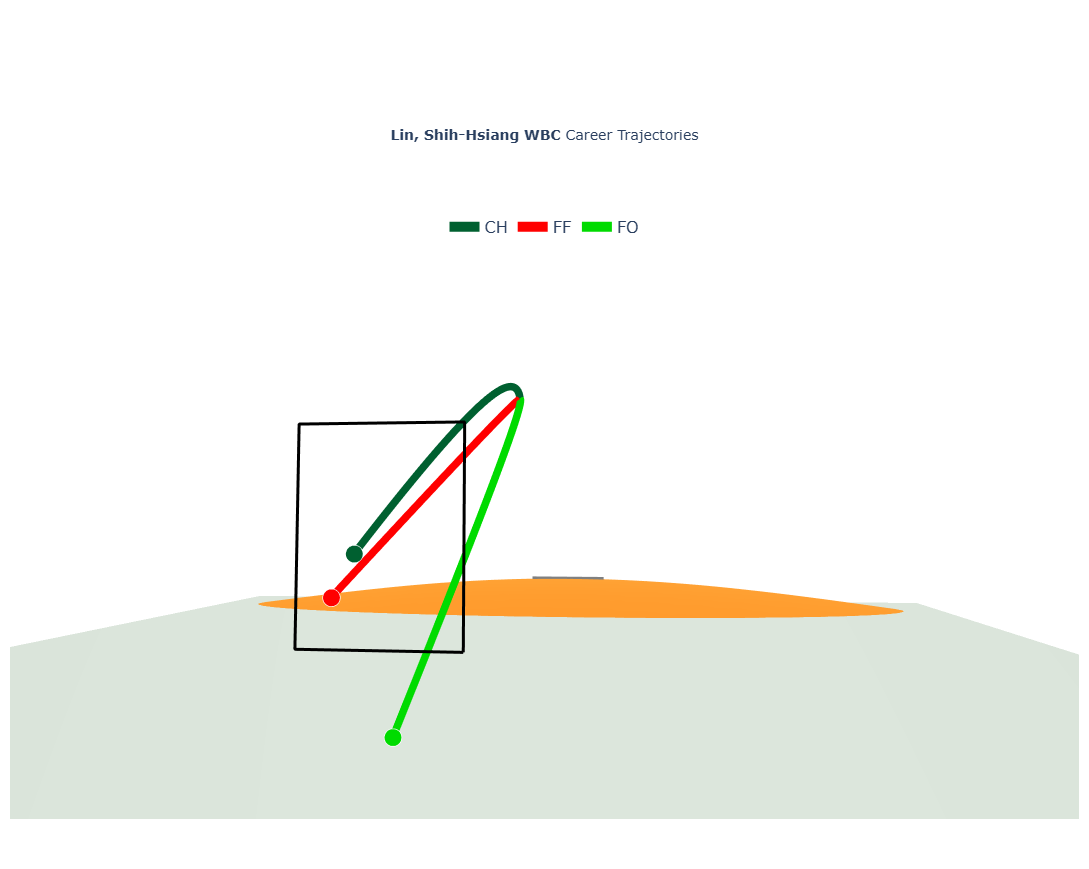

In [98]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import os

# --- 1. 資料預處理與統計量計算 (不分年份，完全沿用第1段欄位) ---
stats_cols = [
    'RelSide', 'RelHeight', 'RelSpeed', 
    'vx0', 'vy0', 'vz0', 
    'ax', 'ay', 'az', 
    'release_pos_y', 'Extension', 'pfx_x', 'pfx_z'
]

# 按球種聚合，計算 mean 與 std
agg_ops = {col: ['mean', 'std'] for col in stats_cols}
avg_df = filtered_data.groupby(['pitch_type']).agg(agg_ops).reset_index()

# 扁平化欄位
avg_df.columns = [f"{col}_{stat}" if stat else col for col, stat in avg_df.columns]

# 出手點中心化基準
mean_rel_side = filtered_data['RelSide'].mean()
mean_rel_height = filtered_data['RelHeight'].mean()

# --- 2. 物理與環境預算 ---
mound_height, mound_radius = 0.8202, 9.0
theta_m = np.linspace(0, 2*np.pi, 50)
r_m = np.linspace(0, mound_radius, 20)
T_m, R_m = np.meshgrid(theta_m, r_m)
m_x_circle, m_y_circle = R_m * np.cos(T_m), R_m * np.sin(T_m) + 60.5
m_z_circle = mound_height * np.cos((R_m / mound_radius) * (np.pi / 2))
rubber_x, rubber_y, rubber_z = [-1, 1], [60.5, 60.5], [mound_height + 0.02] * 2

visual_sz_width = 1.5
sz_top, sz_bottom = 3.5, 1.5
visual_plate_width = 1.42
half_w = visual_plate_width / 2
hp_x, hp_y = [half_w, -half_w, -half_w, 0, half_w], [0, 0, -0.7, -1.2, -0.7]
hp_z = [0.01] * 5
v_sz_x, sz_z = [half_w, -half_w, -half_w, half_w, half_w], [sz_bottom, sz_bottom, sz_top, sz_top, sz_bottom]

# --- 3. 軌跡計算函數 (完全套用第1段 get_trajectory 邏輯) ---
def get_trajectory(row, suffix='_mean'):
    vy0 = row[f'vy0{suffix}']
    ay = row[f'ay{suffix}']
    start_y = row[f'release_pos_y{suffix}']
    
    # 求解時間 t
    a_quad, b_quad, c_quad = 0.5 * ay, vy0, start_y
    delta = max(0, b_quad**2 - 4*a_quad*c_quad)
    t_total = (-b_quad - np.sqrt(delta)) / (2*a_quad)
    t_vals = np.linspace(0, t_total, 100)
    
    x = mean_rel_side + row[f'vx0{suffix}']*t_vals + 0.5*row[f'ax{suffix}']*t_vals**2
    y = start_y + vy0*t_vals + 0.5*ay*t_vals**2
    z = mean_rel_height + row[f'vz0{suffix}']*t_vals + 0.5*row[f'az{suffix}']*t_vals**2
    return x, y, z

# --- 4. 繪製圖表 ---
fig = go.Figure()

# A. 環境繪製
fig.add_trace(go.Surface(x=np.array([[-15, 15], [-15, 15]]), y=np.array([[-5, -5], [75, 75]]), z=np.zeros((2,2)), colorscale=[[0, '#ccd6cc'], [1, '#ccd6cc']], showscale=False, opacity=1, hoverinfo='skip'))
fig.add_trace(go.Surface(x=m_x_circle, y=m_y_circle, z=m_z_circle, colorscale=[[0, '#FF9224'], [1, '#FF9224']], showscale=False, opacity=1, hoverinfo='skip'))
fig.add_trace(go.Scatter3d(x=rubber_x, y=rubber_y, z=rubber_z, mode='lines', line=dict(color='gray', width=6), showlegend=False))
fig.add_trace(go.Mesh3d(x=hp_x, y=hp_y, z=hp_z, color='white', opacity=1, alphahull=0, showlegend=False))
fig.add_trace(go.Scatter3d(x=hp_x + [hp_x[0]], y=hp_y + [hp_y[0]], z=hp_z + [hp_z[0]], mode='lines', line=dict(color='white', width=4), showlegend=False))
fig.add_trace(go.Scatter3d(x=v_sz_x, y=[0]*5, z=sz_z, mode='lines', line=dict(color='black', width=6), showlegend=False))

# B. 軌跡繪製
for _, row in avg_df.iterrows():
    p_color = pitch_colors.get(row['pitch_type'], 'gray')
    
    # 建立 Upper (+1std) 與 Lower (-1std) 數據行 (完全套用第1段邏輯)
    row_up = {f"{c}_mean": row[f"{c}_mean"] + row[f"{c}_std"] for c in stats_cols}
    row_lo = {f"{c}_mean": row[f"{c}_mean"] - row[f"{c}_std"] for c in stats_cols}
    
    # 1. 繪製平均軌跡
    mx, my, mz = get_trajectory(row, '_mean')
    hover_t = (f"<b>{row['pitch_type']} (Career)</b><br>"
               f"Avg Speed: {row['RelSpeed_mean']:.1f} mph<br>"
               f"Avg Horz Mov (pfx_x): {row['pfx_x_mean']:.2f} ft<br>"
               f"Avg Vert Mov (pfx_z): {row['pfx_z_mean']:.2f} ft")
    
    fig.add_trace(go.Scatter3d(
        x=mx, y=my, z=mz, mode='lines',
        line=dict(color=p_color, width=15),
        name=row['pitch_type'], text=hover_t, hoverinfo='text'
    ))

    # 2. 繪製 ±1 Std 軌跡
    for r_bound in [row_up, row_lo]:
        bx, by, bz = get_trajectory(r_bound, '_mean')
        fig.add_trace(go.Scatter3d(
            x=bx, y=by, z=bz, mode='lines',
            line=dict(color=p_color, width=3, dash='dash'),
            opacity=0.4, hoverinfo='skip', showlegend=False
        ))

    # 3. 平均進壘點標記
    fig.add_trace(go.Scatter3d(
        x=[mx[-1]], y=[my[-1]], z=[mz[-1]], 
        mode='markers', marker=dict(color=p_color, size=10, line=dict(color='white', width=1)),
        showlegend=False, hoverinfo='skip'
    ))

# --- 5. 視角設定 (使用第2段視角) ---
camera_setting = dict(eye=dict(x=0.35, y=-2.5, z=-0.2), center=dict(x=0, y=0.5, z=0), up=dict(x=0, y=0, z=1))
scene_config = dict(
    xaxis=dict(range=[-10, 10], visible=False), 
    yaxis=dict(range=[-8, 68], visible=False),
    zaxis=dict(range=[0, 8], visible=False), 
    camera=camera_setting,
    aspectratio=dict(x=3.2, y=3.5, z=1.2),
    aspectmode='manual'
)
fig.update_scenes(**scene_config)

# --- 6. 佈局與輸出 ---
fig.update_layout(
    title=dict(text=f"<b>{pitcher}</b> Career Trajectories", x=0.5, y=0.85, font=dict(size=14)),
    paper_bgcolor='white', 
    margin=dict(l=10, r=10, b=50, t=100),
    legend=dict(orientation="h", yanchor="bottom", y=0.8, xanchor="center", x=0.5, font=dict(size=16)),
    height=850, 
    width=1100
)

# 保存並顯示
save_path = os.path.join(output_dir, f"{pitcher}_Career_ZScore_Trajectories.png")
fig.write_image(save_path, scale=2)
fig.show()

In [82]:
#camera_setting = dict(
 #   eye=dict(x=0, y=-2.2, z=-0.1), 
  #  center=dict(x=0, y=0.5, z=0),
   # up=dict(x=0, y=0, z=0) 
#)